In [24]:
# 1. Setup & Imports
# 2. Synthetic MRI Data Generation
# 3. Baseline Normalization Methods
# 4. Learnable Normalization (Unconditioned) – Ablation
# 5. Class-Conditioned Learnable Normalization (Main Method)
# 6. Loss Design & Regularization
# 7. Results & Visualization
# 8. Discussion Notes (for paper)

# 1. Setup & Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

## 2. Synthetic MRI Intensity Data

In [26]:
def generate_synthetic_mri(n_samples=5000):
    classes = {
        0: ("Normal", 0.0, 1.0),
        1: ("Edema", 0.5, 1.2),
        2: ("Enhancing", 1.0, 1.1),
    }

    X, y = [], []
    for label, (_, mu, sigma) in classes.items():
        X.append(np.random.normal(mu, sigma, n_samples))
        y.append(np.full(n_samples, label))

    return np.concatenate(X), np.concatenate(y), classes

X, y, classes = generate_synthetic_mri()

## 3. Baseline: Fixed PDF Intensity Mapping

In [27]:
target_means = {0: -0.5, 1: 0.0, 2: 0.5}
target_std = 0.1

def fixed_pdf_mapping(x, labels):
    out = np.zeros_like(x)
    for k in np.unique(labels):
        xk = x[labels == k]
        out[labels == k] = target_means[k] + \
                           (xk - xk.mean()) * (target_std / (xk.std() + 1e-6))
    return out

X_pdf = fixed_pdf_mapping(X, y)

In [28]:
def zscore_norm(x):
    mean = np.mean(x)
    std = np.std(x) + 1e-8
    return (x - mean) / std

In [29]:
X_z = zscore_norm(X)

## 4. Ablation: Unconditioned Learnable Normalization

In [30]:
class LearnableIntensityNorm(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.mu = layers.Dense(1)
        self.sigma = layers.Dense(1, activation="softplus")
        self.gamma = layers.Dense(1)
        self.beta = layers.Dense(1)

    def call(self, x):
        mu = self.mu(x)
        sigma = self.sigma(x) + 1e-6
        x_norm = (x - mu) / sigma
        return self.gamma(x_norm) + self.beta(x_norm)

## 5. Proposed Method: Class-Conditioned Learnable Normalization (CLIN)

In [31]:
class ClassConditionedLIN(tf.keras.Model):
    def __init__(self, num_classes):
        super().__init__()
        self.fc = layers.Dense(16, activation="relu")
        self.mu = layers.Dense(1)
        self.sigma = layers.Dense(1, activation="softplus")
        self.gamma = layers.Dense(1)
        self.beta = layers.Dense(1)

    def call(self, x, y_cond):
        h = self.fc(tf.concat([x, y_cond], axis=1))
        mu = self.mu(h)
        sigma = self.sigma(h) + 1e-6
        x_norm = (x - mu) / sigma
        return self.gamma(x_norm) + self.beta(x_norm)

In [32]:
X_tf = tf.convert_to_tensor(X.reshape(-1,1), tf.float32)
y_tf = tf.convert_to_tensor(y, tf.int32)
y_onehot = tf.one_hot(y_tf, depth=3)

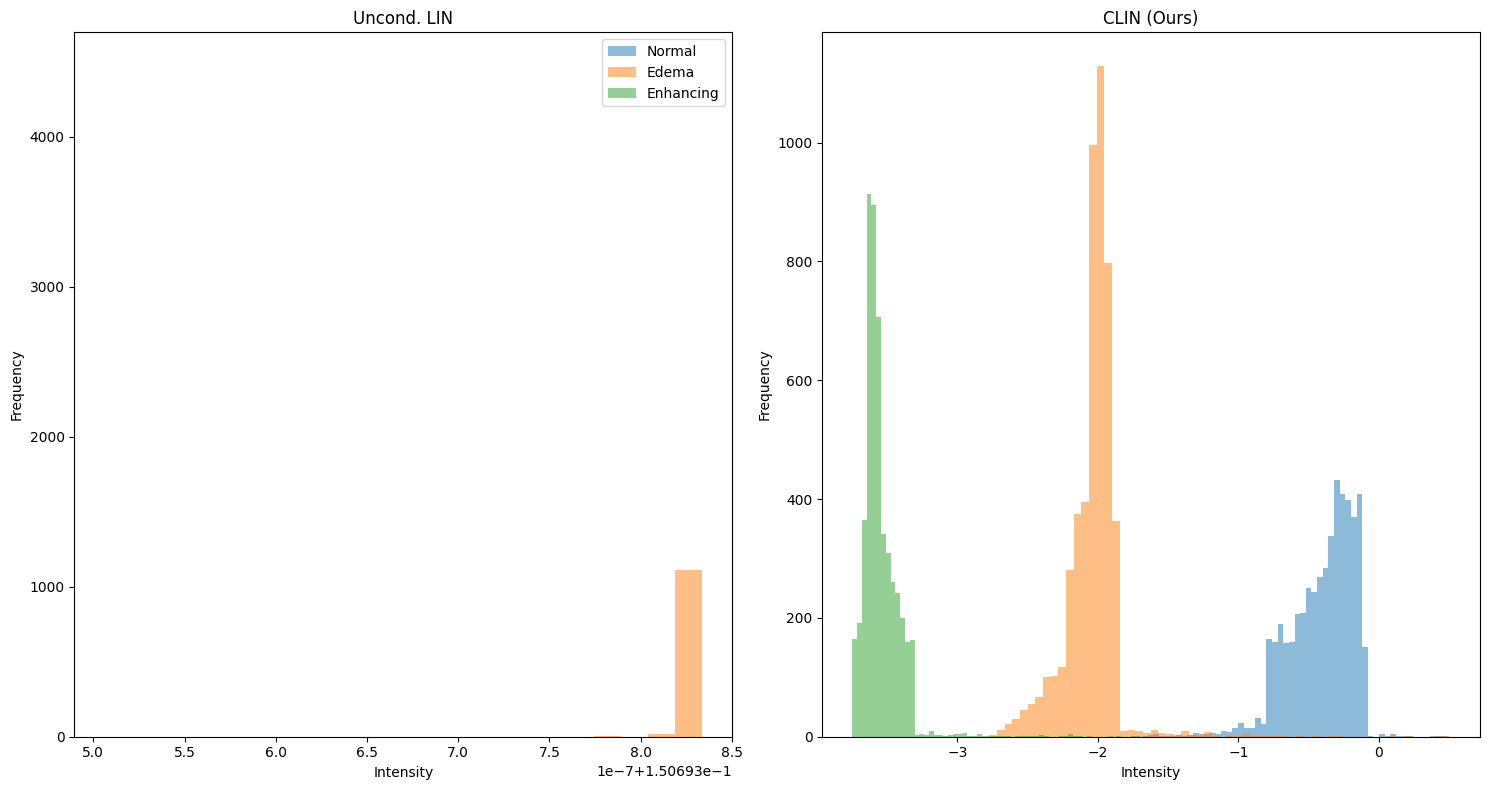

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
axes = axes.flatten()

methods = {
    "Uncond. LIN": X_lin,
    "CLIN (Ours)": X_clin
}

for ax, (title, data) in zip(axes, methods.items()):
    for k, (name, _, _) in classes.items():
        ax.hist(data[y == k], bins=60, alpha=0.5, label=name)
    ax.set_title(title)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Frequency")

# Turn off the last unused subplot
# axes[-1].axis("off")

# One legend for the whole figure
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.savefig("ablation.pdf")
plt.show()

## 6. Loss Function and Regularization

In [33]:
target_variance = 0.1

In [34]:
def separation_loss(x, labels):
    loss = 0.0
    classes = tf.unique(labels)[0]
    for i in classes:
        xi = tf.boolean_mask(x, labels == i)
        mu_i = tf.reduce_mean(xi)
        var_i = tf.math.reduce_variance(xi)
        for j in classes:
            if i != j:
                xj = tf.boolean_mask(x, labels == j)
                mu_j = tf.reduce_mean(xj)
                loss += var_i / ((mu_i - mu_j)**2 + 1e-6)
    return loss

In [35]:
target_means = {0: 0.0, 1: -2.0, 2: -4.0}

def mean_anchor_loss(x, labels, weight=0.1):
    loss = 0.0
    for k, mu_t in target_means.items():
        mu_k = tf.reduce_mean(tf.boolean_mask(x, labels == k))
        loss += tf.square(mu_k - mu_t)
    return weight * loss

In [53]:
def variance_anchor_loss(x, labels, target_var=0.5, weight=0.02):
    loss = 0.0
    for k in tf.unique(labels)[0]:
        xk = tf.boolean_mask(x, labels == k)
        var_k = tf.math.reduce_variance(xk)
        loss += tf.square(var_k - target_var)
    return weight * loss

In [54]:
def ordering_loss(x, labels, margin=0.5, weight=0.1):
    means = {}
    for k in tf.unique(labels)[0]:
        means[int(k.numpy())] = tf.reduce_mean(
            tf.boolean_mask(x, labels == k)
        )

    loss = 0.0
    if 0 in means and 1 in means:
        loss += tf.nn.relu(means[0] - means[1] + margin)
    if 1 in means and 2 in means:
        loss += tf.nn.relu(means[1] - means[2] + margin)

    return weight * loss

In [55]:
def total_loss(x, labels):
    return (
        separation_loss(x, labels)
        + mean_anchor_loss(x, labels)
        + variance_anchor_loss(x, labels)
        + ordering_loss(x, labels)
    )

In [77]:
def loss_sep_only(x, labels):
    return separation_loss(x, labels)

def loss_sep_mean(x, labels):
    return separation_loss(x, labels) + mean_anchor_loss(x, labels)

def loss_sep_var(x, labels):
    return separation_loss(x, labels) + variance_anchor_loss(x, labels)

def loss_full(x, labels):
    return (
        separation_loss(x, labels)
        + mean_anchor_loss(x, labels)
        + variance_anchor_loss(x, labels)
    )

## 7. Training

In [56]:
X_tf = tf.convert_to_tensor(X.reshape(-1, 1), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y, dtype=tf.int32)
y_onehot = tf.one_hot(y_tf, depth=3)

In [57]:
lin_model = LearnableIntensityNorm()
clin_model = ClassConditionedLIN(num_classes=3)

In [58]:
lin_model = LearnableIntensityNorm()
optimizer_lin = tf.keras.optimizers.Adam(0.01)

for epoch in range(300):
    with tf.GradientTape() as tape:
        X_out = lin_model(X_tf)
        loss = separation_loss(X_out, y_tf)   # SAME loss, no conditioning

    grads = tape.gradient(loss, lin_model.trainable_variables)
    optimizer_lin.apply_gradients(zip(grads, lin_model.trainable_variables))

    if epoch % 50 == 0:
        print(f"[LIN] epoch {epoch}, loss {loss.numpy():.4f}")

[LIN] epoch 0, loss 1162.6375
[LIN] epoch 50, loss 33.2468
[LIN] epoch 100, loss 27.7962
[LIN] epoch 150, loss 0.3781
[LIN] epoch 200, loss 0.0010
[LIN] epoch 250, loss 0.0000


In [59]:
X_lin = lin_model(X_tf).numpy().flatten()

In [60]:
clin_model = ClassConditionedLIN(num_classes=3)
optimizer = tf.keras.optimizers.Adam(0.01)

for epoch in range(300):
    with tf.GradientTape() as tape:
        X_out = clin_model(X_tf, y_onehot)
        loss = total_loss(X_out, y_tf)

    grads = tape.gradient(loss, clin_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, clin_model.trainable_variables))

    if epoch % 50 == 0:
        print(f"epoch {epoch}, loss {loss.numpy():.4f}")

epoch 0, loss 71.1142
epoch 50, loss 2.9206
epoch 100, loss 1.8091
epoch 150, loss 1.5288
epoch 200, loss 1.3650
epoch 250, loss 1.2387


In [61]:
X_clin = clin_model(X_tf, y_onehot).numpy().flatten()

In [62]:
for name in ["X", "X_z", "X_pdf", "X_lin", "X_clin"]:
    print(name, "exists:", name in globals())

X exists: True
X_z exists: True
X_pdf exists: True
X_lin exists: True
X_clin exists: True


## 8. Results

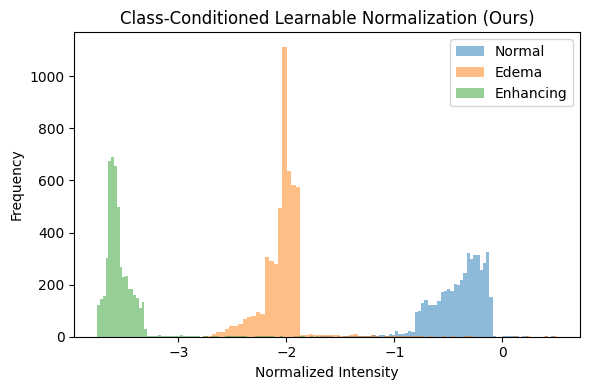

In [63]:
X_clin = model(X_tf, y_onehot).numpy().flatten()

plt.figure(figsize=(6,4))
for k, (name, _, _) in classes.items():
    plt.hist(X_clin[y==k], bins=80, alpha=0.5, label=name)

plt.title("Class-Conditioned Learnable Normalization (Ours)")
plt.xlabel("Normalized Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Comparative Results

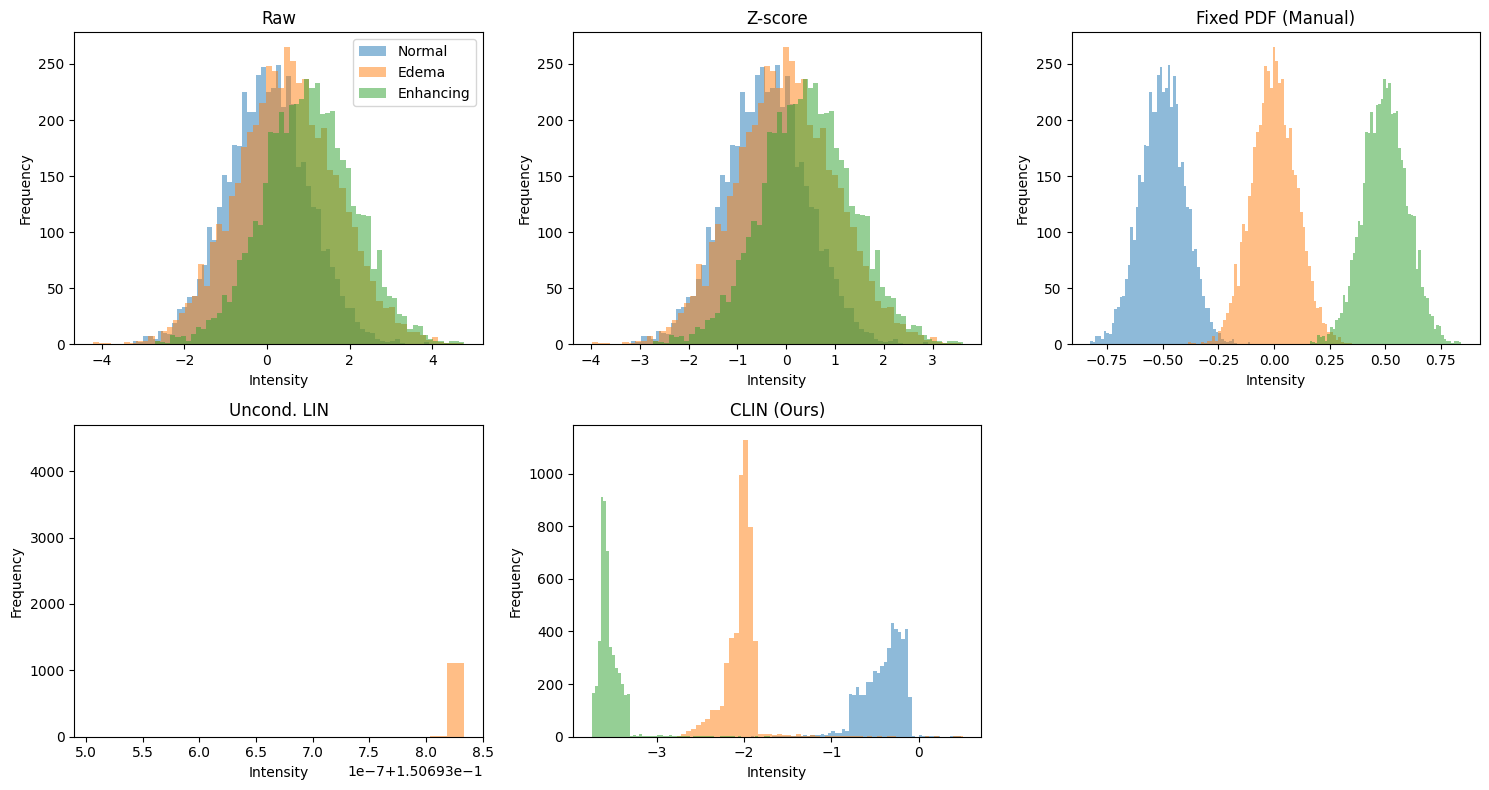

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

methods = {
    "Raw": X,
    "Z-score": X_z,
    "Fixed PDF (Manual)": X_pdf,
    "Uncond. LIN": X_lin,
    "CLIN (Ours)": X_clin
}

for ax, (title, data) in zip(axes, methods.items()):
    for k, (name, _, _) in classes.items():
        ax.hist(data[y == k], bins=60, alpha=0.5, label=name)
    ax.set_title(title)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Frequency")

# Turn off the last unused subplot
axes[-1].axis("off")

# One legend for the whole figure
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.savefig("figure.pdf")
plt.show()

## Quantitative Separability Analysis

In [65]:
def fisher_discriminant_ratio(x, labels):
    classes = np.unique(labels)
    
    means = []
    variances = []
    
    for k in classes:
        xk = x[labels == k]
        means.append(np.mean(xk))
        variances.append(np.var(xk))
    
    means = np.array(means)
    variances = np.array(variances)
    
    inter_class = np.sum((means - means.mean())**2)
    intra_class = np.sum(variances)
    
    return inter_class / (intra_class + 1e-8)

In [68]:
methods = {
    "Raw": X,
    "Z-score": X_z,
    "Fixed PDF": X_pdf,
    "Uncond. LIN": X_lin,
    "CLIN (Ours)": X_clin
}

for name, data in methods.items():
    value = fisher_discriminant_ratio(data, y)
    print(f"{name:15s}: {value:.3f}")

Raw            : 0.138
Z-score        : 0.138
Fixed PDF      : 16.667
Uncond. LIN    : 0.000
CLIN (Ours)    : 42.884


In [80]:
def train_and_evaluate(loss_fn, epochs=300):
    model = ClassConditionedLIN(num_classes=3)
    optimizer = tf.keras.optimizers.Adam(0.01)

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            X_out = model(X_tf, y_onehot)
            loss = loss_fn(X_out, y_tf)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # inference
    X_out = model(X_tf, y_onehot).numpy().flatten()
    return fisher_discriminant_ratio(X_out, y)

In [ ]:
results = {
    "Separation only": train_and_evaluate(loss_sep_only),
    "Separation + Mean anchoring": train_and_evaluate(loss_sep_mean),
    "Separation + Variance anchoring": train_and_evaluate(loss_sep_var),
    "Full CLIN": train_and_evaluate(loss_full),
}

for k, v in results.items():
    print(f"{k:20s}: {v:.3f}")

Separation only     : 45.149
+ Mean anchoring    : 23.878
+ Variance anchoring: 1.622
Full CLIN           : 1328.464
